# Cálculo de Performance de Bomba — API 610

1. Configuração do ambiente  
2. Dados de entrada (ponto nominal + pontos de ensaio)  
3. Correção de pontos para rotação nominal (leis de semelhança)  
4. Ajuste de curva: **polinômio grau 3** e **spline cúbica natural**  
5. Visualizações Q×H, Q×P, Q×η  
6. Avaliação de desvios e tolerâncias **API 610**  
7. Exportação do relatório em arquivo de dados

## 1 · Configurar Ambiente

Apenas bibliotecas da **biblioteca padrão** do Python (`math`, `json`, `dataclasses`) são necessárias para os cálculos.  
`matplotlib` é opcional — usada apenas para os gráficos.

In [3]:
from __future__ import annotations

import json
import math
import tkinter as tk
from tkinter import ttk, messagebox, filedialog
from dataclasses import dataclass
from typing import List, Optional

try:
    import matplotlib
    from matplotlib.figure import Figure as MplFigure
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib não encontrado — gráficos desabilitados")

G = 9.80665  # m/s²

print("Ambiente configurado.")


Ambiente configurado.


## 2 · Entrada de Dados via Janela Interativa

Ao executar a célula abaixo, uma **janela tkinter** é aberta com:

| Seção | Campos |
|---|---|
| Ponto Nominal | TAG, Q, H, N, P, densidades, viscosidade nominal, head shutoff |
| Unidade de pressão | `kgf/cm²` ou `bar` |
| Pontos de Ensaio | tabela com Q, **P sucção**, **P descarga**, **Temperatura da água**, Head calculado, Potência, N |
| Ação principal | botão **Calcular e gerar gráficos** |

> O head dos pontos de ensaio é calculado automaticamente por: `H = (Pdesc - Psuc) / (ρ·g)`.

In [4]:
@dataclass
class TestPoint:
    """Ponto medido no banco de ensaio."""
    q_m3h: float
    head_m: float
    power_kw: float
    n_rpm: float
    eff: Optional[float] = None
    temp_test_c: Optional[float] = None
    density_test_kgm3: Optional[float] = None


@dataclass
class RatedData:
    """Ponto nominal (folha de dados)."""
    q_m3h: float
    head_m: float
    power_kw: float
    n_rpm: float
    standard: str = "API610 (12a ed.) / ISO 13709 + N-553"
    parallel_operation: bool = False
    eff: Optional[float] = None
    head_shutoff_m: Optional[float] = None
    density_rated_rel: float = 0.983
    density_rated_kgm3: float = 983.0
    viscosity_nom_cst: float = 1.0
    density_test_kgm3: float = 983.0


PRESSURE_UNITS = {"kgf/cm²": 98066.5, "bar": 100000.0}


def water_density_kgm3(temp_c: float) -> float:
    """Densidade da água pura (kg/m³) em função da temperatura [°C]."""
    # Polinômio empírico para água pura em 1 atm (faixa prática 0–100 °C).
    if temp_c < 0 or temp_c > 100:
        raise ValueError("Temperatura da água de ensaio deve estar entre 0 e 100 °C.")
    t = temp_c
    return (
        999.842594
        + 6.793952e-2 * t
        - 9.095290e-3 * t**2
        + 1.001685e-4 * t**3
        - 1.120083e-6 * t**4
        + 6.536332e-9 * t**5
    )


def pressure_to_head(p_suc: float, p_dis: float, unit: str, density_kgm3: float) -> float:
    dp_pa = (p_dis - p_suc) * PRESSURE_UNITS[unit]
    return dp_pa / (density_kgm3 * G)


def calc_efficiency(q_m3h: float, head_m: float, power_kw: float, density_kgm3: float) -> float:
    """Eficiência hidráulica estimada a partir de Q, H e P."""
    if power_kw <= 0 or q_m3h <= 0:
        return 0.0
    q_m3s = q_m3h / 3600.0
    p_hyd_w = density_kgm3 * G * q_m3s * head_m
    return p_hyd_w / (power_kw * 1000.0)


def viscosity_correction_factors(nu_cst: float) -> tuple[float, float, float]:
    """Retorna fatores (f_head, f_power, f_eff) para viscosidade nominal em cSt."""
    if nu_cst <= 1.5:
        return 1.0, 1.0, 1.0
    x = max(0.0, math.log10(nu_cst))
    f_head = max(0.75, 1.0 - 0.03 * x)
    f_power = 1.0 + 0.04 * x
    f_eff = max(0.65, 1.0 - 0.05 * x)
    return f_head, f_power, f_eff


def _show_plots_window(parent, fig, tag: str):
    """Embute a figura matplotlib (backend-agnostic) em uma janela tkinter."""
    from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk

    win = tk.Toplevel(parent) if parent else tk.Tk()
    win.title(f"Curvas de Performance — {tag} | API 610")
    win.resizable(True, True)
    win.minsize(1100, 720)
    try:
        win.state("zoomed")
    except Exception:
        win.update_idletasks()
        sw, sh = win.winfo_screenwidth(), win.winfo_screenheight()
        win.geometry(f"{max(1100, int(sw * 0.95))}x{max(720, int(sh * 0.92))}+0+0")
    win.configure(padx=10, pady=10)

    main_pane = ttk.Panedwindow(win, orient="horizontal")
    main_pane.pack(side="top", fill="both", expand=True)

    plot_frame = ttk.Frame(main_pane)
    results_frame = ttk.Frame(main_pane)
    main_pane.add(plot_frame, weight=3)
    main_pane.add(results_frame, weight=2)

    canvas = FigureCanvasTkAgg(fig, master=plot_frame)
    canvas.draw()

    # pack_toolbar=False evita duplo pack em versões recentes do matplotlib
    try:
        toolbar = NavigationToolbar2Tk(canvas, plot_frame, pack_toolbar=False)
    except TypeError:
        toolbar = NavigationToolbar2Tk(canvas, plot_frame)
    toolbar.update()

    # Ordem: toolbar em cima e canvas no meio.
    toolbar.pack(side="top", fill="x")
    canvas.get_tk_widget().pack(side="top", fill="both", expand=True)

    # Área reservada para a tabela de resultados na mesma janela.
    win._results_container = results_frame
    return win


def _show_results_window(parent, tag: str, rated: RatedData,
                          h_poly, h_spln, p_poly, p_spln,
                          e_poly, e_spln, h0_poly, h0_spln,
                          fig=None) -> None:
    """Abre janela tkinter com tabela de resultados e parecer API 610."""

    def _norm_criteria(standard: str, h_val: float) -> dict:
        if standard.startswith("API610"):
            power_tol = 0.03 if h_val <= 75 else (0.08 if h_val <= 300 else 0.05)
            return {"head": 0.03, "power": power_tol, "eff": power_tol, "shutoff": power_tol}
        if standard.startswith("ASME B73"):
            return {"head": 0.05, "power": 0.10, "eff": 0.07, "shutoff": 0.10}
        if standard.startswith("ISO 5199"):
            return {"head": 0.05, "power": 0.08, "eff": 0.06, "shutoff": 0.08}
        return {"head": 0.03, "power": 0.08, "eff": 0.08, "shutoff": 0.08}

    def _dev(nominal, predicted):
        if nominal is None or predicted is None or predicted == 0:
            return None
        return 1.0 - nominal / predicted

    criteria = _norm_criteria(getattr(rated, "standard", ""), rated.head_m)
    tH = criteria["head"]
    tP = criteria["power"]
    tE = criteria["eff"]
    tS = criteria["shutoff"]

    rows = [
        ("Altura H — polinômio",     rated.head_m,         h_poly,  tH),
        ("Altura H — spline",        rated.head_m,         h_spln,  tH),
        ("Potência P — polinômio",   rated.power_kw,       p_poly,  tP),
        ("Potência P — spline",      rated.power_kw,       p_spln,  tP),
        ("Eficiência η — polinômio", rated.eff,            e_poly,  tE),
        ("Eficiência η — spline",    rated.eff,            e_spln,  tE),
        ("H shutoff — polinômio",    rated.head_shutoff_m, h0_poly, tS),
        ("H shutoff — spline",       rated.head_shutoff_m, h0_spln, tS),
    ]
    if getattr(rated, "parallel_operation", False):
        _h_min_par = round(1.10 * rated.head_m, 6)
        rows += [
            ("H shutoff ≥110% (paralelo) — polinômio", _h_min_par, h0_poly, None),
            ("H shutoff ≥110% (paralelo) — spline",          _h_min_par, h0_spln, None),
        ]

    def _build_report_payload(report_rows):
        additional_criteria = {
            "ruido": "Abaixo de 85 dB",
            "vazamento_selo": "Sem vazamento visível",
        }
        if getattr(rated, "standard", "").startswith("API610"):
            additional_criteria["vibracao_api610"] = [
                "Vibracao global (overall) | Velocidade [mm/s RMS] | Mancal da bomba | BEP/POR | <= 3,0",
                "Vibracao filtrada/discreta (1x RPM) | Velocidade [mm/s RMS] | Mancal (FFT) | BEP/POR | <= 2,0",
                "Vibracao global fora da POR (AOR) | Velocidade [mm/s RMS] | Mancal da bomba | <= 3,9 (+30%)",
                "Vibracao discreta fora da POR (AOR) | Velocidade [mm/s RMS] | Mancal (FFT) | <= 2,6 (+30%)",
                "Vibracao global - bombas verticais | Velocidade [mm/s RMS] | Mancal da bomba | BEP/POR",
            ]
        return {
            "bomba": tag,
            "norma": getattr(rated, "standard", "API610 (12a ed.) / ISO 13709 + N-553"),
            "ponto_nominal": rated.__dict__,
            "predicoes_ponto_nominal": {
                "head_poly_m": h_poly,
                "head_spline_m": h_spln,
                "power_poly_kw": p_poly,
                "power_spline_kw": p_spln,
                "eff_poly": e_poly,
                "eff_spline": e_spln,
                "head_shutoff_poly_m": h0_poly,
                "head_shutoff_spline_m": h0_spln,
            },
            "tolerancias": {"head": tH, "power": tP, "eff": tE, "shutoff": tS},
            "operacao_paralelo": getattr(rated, "parallel_operation", False),
            "shutoff_min_paralelo_m": round(1.10 * rated.head_m, 4) if getattr(rated, "parallel_operation", False) else None,
            "criterios_adicionais": additional_criteria,
            "resultados": report_rows,
        }

    if parent is not None and hasattr(parent, "_results_container"):
        win = parent
        container = parent._results_container
        for child in container.winfo_children():
            child.destroy()
    else:
        win = tk.Toplevel(parent) if parent else tk.Tk()
        win.title(f"Resultados API 610 — {tag}")
        win.resizable(True, True)
        try:
            win.state("zoomed")
        except Exception:
            pass
        win.configure(padx=14, pady=14)
        container = win
        if parent:
            try:
                win.transient(parent)
            except Exception:
                pass

    for col in range(6):
        container.columnconfigure(col, weight=1)

    report_rows = []

    ttk.Label(container, text=f"Bomba: {tag}  |  Norma: {getattr(rated, 'standard', 'API610 (12a ed.) / ISO 13709 + N-553')}",
              font=("TkDefaultFont", 11, "bold")).grid(
        row=0, column=0, columnspan=6, sticky="w", pady=(0, 10))

    ttk.Label(container,
              text=f"Q nominal: {rated.q_m3h} m³/h  |  H nominal: {rated.head_m} m  |  N nominal: {rated.n_rpm} rpm",
              foreground="gray").grid(
        row=1, column=0, columnspan=6, sticky="w", pady=(0, 8))

    headers = ["Parâmetro", "Nominal", "Predito", "Desvio", "Tolerância", "Parecer"]
    col_widths = [26, 10, 10, 9, 10, 14]
    for col, (hdr, w) in enumerate(zip(headers, col_widths)):
        ttk.Label(container, text=hdr, anchor="center", relief="groove",
                  padding=(6, 4), width=w).grid(
            row=2, column=col, sticky="ew", padx=1)

    for r, (name, nom, pred, tol) in enumerate(rows, start=3):
        dev = _dev(nom, pred)
        nom_s  = f"{nom:.4f}"  if nom  is not None else "N/A"
        pred_s = f"{pred:.4f}" if pred is not None else "N/A"
        dev_s  = f"{dev*100:+.2f}%" if dev is not None else "N/A"
        tol_s  = "mínimo" if tol is None else f"±{tol*100:.0f}%"
        if dev is None:
            approved = False
        elif "≥110%" in name:
            approved = pred is not None and nom is not None and pred >= nom
        elif name.startswith("Potência"):
            approved = dev <= tol
        elif name.startswith("Eficiência"):
            approved = dev >= -tol
        else:
            approved = abs(dev) <= tol
        parecer = "✅ APROVADO" if approved else ("❌ REPROVADO" if dev is not None else "N/A")
        bg_color = "#d4edda" if approved else ("#f8d7da" if dev is not None else "#ffffff")
        report_rows.append({
            "parametro": name,
            "nominal": nom,
            "predito": pred,
            "desvio": dev,
            "tolerancia": tol,
            "parecer": parecer,
        })

        for col, (txt, w) in enumerate(zip([name, nom_s, pred_s, dev_s, tol_s, parecer], col_widths)):
            anchor = "w" if col == 0 else "center"
            fnt = ("TkDefaultFont", 9, "bold") if col == 5 else ("TkDefaultFont", 9)
            tk.Label(container, text=txt, anchor=anchor, padx=6, pady=3,
                     width=w, background=bg_color, relief="flat", font=fnt).grid(
                row=r, column=col, sticky="ew", padx=1, pady=1)

    ttk.Separator(container, orient="horizontal").grid(
        row=len(rows) + 3, column=0, columnspan=6, sticky="ew", pady=8)

    req_row = len(rows) + 4
    ttk.Label(container, text="Demais requisitos para o teste",
              font=("TkDefaultFont", 10, "bold")).grid(
        row=req_row, column=0, columnspan=6, sticky="w", pady=(0, 6))
    req_row += 1
    ttk.Label(container, text="Ruido: Abaixo de 85 dB", foreground="#333333").grid(
        row=req_row, column=0, columnspan=6, sticky="w", pady=(0, 4))
    req_row += 1
    ttk.Label(container, text="Vazamento no selo: Sem vazamento visivel", foreground="#333333").grid(
        row=req_row, column=0, columnspan=6, sticky="w", pady=(0, 6))
    req_row += 1

    if getattr(rated, "standard", "").startswith("API610"):
        ttk.Label(container, text="Criterios de vibracao - Bombas API 610",
                  font=("TkDefaultFont", 9, "bold")).grid(
            row=req_row, column=0, columnspan=6, sticky="w", pady=(2, 4))
        req_row += 1
        vib_lines = [
            "Vibracao global (overall): Velocidade [mm/s RMS] | Mancal da bomba | BEP/POR | <= 3,0",
            "Vibracao filtrada/discreta (1x RPM): Velocidade [mm/s RMS] | Mancal (FFT) | BEP/POR | <= 2,0",
            "Vibracao global fora da POR (AOR): Velocidade [mm/s RMS] | Mancal da bomba | <= 3,9 (+30%)",
            "Vibracao discreta fora da POR (AOR): Velocidade [mm/s RMS] | Mancal (FFT) | <= 2,6 (+30%)",
            "Vibracao global - bombas verticais: Velocidade [mm/s RMS] | Mancal da bomba | BEP/POR",
        ]
        for line in vib_lines:
            tk.Label(container, text=f"- {line}", anchor="w", justify="left",
                     wraplength=780).grid(
                row=req_row, column=0, columnspan=6, sticky="w", pady=(0, 2))
            req_row += 1

    def _save_results_json():
        try:
            payload = _build_report_payload(report_rows)
            path = filedialog.asksaveasfilename(
                parent=win,
                title="Salvar dados",
                defaultextension=".json",
                initialfile=f"{tag}_api611_resultado.json",
                filetypes=[("Arquivo de dados", "*.json"), ("Todos os arquivos", "*.*")],
            )
            if not path:
                return
            with open(path, "w", encoding="utf-8") as f:
                json.dump(payload, f, indent=2, ensure_ascii=False)
            messagebox.showinfo("Exportação concluída", f"Relatório de arquivo de dados salvo em:\n{path}", parent=win)
        except Exception as exc:
            messagebox.showerror("Erro", f"Falha ao salvar arquivo de dados:\n{exc}", parent=win)

    def _export_word_report():
        try:
            import io, base64
            payload = _build_report_payload(report_rows)
            path = filedialog.asksaveasfilename(
                parent=win,
                title="Exportar relatório para Word",
                defaultextension=".doc",
                initialfile=f"{tag}_api611_relatorio.doc",
                filetypes=[("Documento Word", "*.doc"), ("HTML", "*.html"), ("Todos os arquivos", "*.*")],
            )
            if not path:
                return
            img_tag = ""
            if fig is not None:
                buf = io.BytesIO()
                fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
                buf.seek(0)
                b64 = base64.b64encode(buf.read()).decode()
                img_tag = f"<p><img src='data:image/png;base64,{b64}' style='max-width:100%;'/></p>"
            html_rows = "".join(
                f"<tr><td>{r['parametro']}</td><td>{r['nominal'] if r['nominal'] is not None else 'N/A'}</td><td>{r['predito'] if r['predito'] is not None else 'N/A'}</td><td>{r['desvio'] if r['desvio'] is not None else 'N/A'}</td><td>{r['tolerancia']}</td><td>{r['parecer']}</td></tr>"
                for r in payload['resultados']
            )
            html = f"""<!doctype html><html><head><meta charset='utf-8'><title>Relatório de Performance</title></head><body><h2>Relatório de Performance - {tag}</h2><p>Norma: {payload['norma']}</p><p>Q nominal: {rated.q_m3h} m³/h | H nominal: {rated.head_m} m | N nominal: {rated.n_rpm} rpm</p>{img_tag}<table border='1' cellspacing='0' cellpadding='5'><tr><th>Parâmetro</th><th>Nominal</th><th>Predito</th><th>Desvio</th><th>Tolerância</th><th>Parecer</th></tr>{html_rows}</table></body></html>"""
            with open(path, "w", encoding="utf-8") as f:
                f.write(html)
            messagebox.showinfo("Exportação concluída", f"Relatório Word salvo em:\n{path}", parent=win)
        except Exception as exc:
            messagebox.showerror("Erro", f"Falha ao exportar Word:\n{exc}", parent=win)

    actions = ttk.Frame(container)
    actions.grid(row=req_row, column=0, columnspan=6, sticky="e", pady=(6, 4))
    ttk.Button(actions, text="Salvar dados", width=18, command=_save_results_json).pack(side="left", padx=4)
    ttk.Button(actions, text="Exportar Word", width=14, command=_export_word_report).pack(side="left", padx=4)
    ttk.Button(actions, text="Fechar", width=12, command=win.destroy).pack(side="left", padx=4)


def _run_full_calculation_and_plot(rated: RatedData, points: List[TestPoint],
                                    tag: str, parent=None) -> None:
    """Executa correção, ajuste de curvas, plota gráficos e abre janela de resultados."""

    @dataclass
    class CorrectedPoint:
        q_m3h: float
        head_m: float
        power_kw: float
        eff: float

    def hydraulic_efficiency(q_m3h: float, head_m: float, power_kw: float,
                              density_kgm3: float) -> float:
        if power_kw <= 0 or q_m3h <= 0:
            return 0.0
        q_m3s = q_m3h / 3600.0
        p_hyd_w = density_kgm3 * G * q_m3s * head_m
        return p_hyd_w / (power_kw * 1000.0)

    def correct_point(pt: TestPoint, rated_data: RatedData) -> CorrectedPoint:
        ratio_n = rated_data.n_rpm / pt.n_rpm
        test_density = pt.density_test_kgm3 if pt.density_test_kgm3 else rated_data.density_test_kgm3
        rho_fac = rated_data.density_rated_kgm3 / test_density
        f_head, f_power, f_eff = viscosity_correction_factors(rated_data.viscosity_nom_cst)
        qc = pt.q_m3h * ratio_n
        hc = pt.head_m * ratio_n ** 2 * f_head
        pc = pt.power_kw * ratio_n ** 3 * rho_fac * f_power
        base_eff = pt.eff if pt.eff is not None else hydraulic_efficiency(qc, hc, pc, rated_data.density_rated_kgm3)
        ec = base_eff * f_eff
        return CorrectedPoint(q_m3h=qc, head_m=hc, power_kw=pc, eff=ec)

    def gauss_solve(a: List[List[float]], b: List[float]) -> List[float]:
        n = len(b)
        aug = [row[:] + [b[i]] for i, row in enumerate(a)]
        for col in range(n):
            pivot = max(range(col, n), key=lambda r: abs(aug[r][col]))
            aug[col], aug[pivot] = aug[pivot], aug[col]
            div = aug[col][col]
            if abs(div) < 1e-14:
                raise ValueError("Sistema singular")
            for j in range(col, n + 1):
                aug[col][j] /= div
            for r in range(n):
                if r == col:
                    continue
                f = aug[r][col]
                for j in range(col, n + 1):
                    aug[r][j] -= f * aug[col][j]
        return [aug[i][n] for i in range(n)]

    def fit_poly(x: List[float], y: List[float], deg: int = 3) -> List[float]:
        n = deg + 1
        ata = [[0.0] * n for _ in range(n)]
        atb = [0.0] * n
        for xi, yi in zip(x, y):
            pw = [xi ** k for k in range(n)]
            for i in range(n):
                atb[i] += pw[i] * yi
                for j in range(n):
                    ata[i][j] += pw[i] * pw[j]
        return gauss_solve(ata, atb)

    def poly_eval(coeffs: List[float], x: float) -> float:
        return sum(c * x ** k for k, c in enumerate(coeffs))

    class NaturalCubicSpline:
        def __init__(self, x: List[float], y: List[float]) -> None:
            pts = sorted(zip(x, y))
            self.x = [p[0] for p in pts]
            self.y = [p[1] for p in pts]
            self._build()

        def _build(self) -> None:
            n = len(self.x)
            hs = [self.x[i + 1] - self.x[i] for i in range(n - 1)]
            a = [0.0] * n
            b = [1.0] * n
            c = [0.0] * n
            d = [0.0] * n
            b[-1] = 1.0
            for i in range(1, n - 1):
                a[i] = hs[i - 1]
                b[i] = 2 * (hs[i - 1] + hs[i])
                c[i] = hs[i]
                d[i] = 6 * ((self.y[i + 1] - self.y[i]) / hs[i] - (self.y[i] - self.y[i - 1]) / hs[i - 1])
            for i in range(1, n):
                w = a[i] / b[i - 1] if b[i - 1] else 0.0
                b[i] -= w * c[i - 1]
                d[i] -= w * d[i - 1]
            m = [0.0] * n
            m[-1] = d[-1] / b[-1]
            for i in range(n - 2, -1, -1):
                m[i] = (d[i] - c[i] * m[i + 1]) / b[i]
            self.m = m
            self.hs = hs

        def eval(self, xq: float) -> float:
            n = len(self.x)
            if xq <= self.x[0]:
                s = (self.y[1] - self.y[0]) / (self.x[1] - self.x[0])
                return self.y[0] + s * (xq - self.x[0])
            if xq >= self.x[-1]:
                s = (self.y[-1] - self.y[-2]) / (self.x[-1] - self.x[-2])
                return self.y[-1] + s * (xq - self.x[-1])
            for i in range(n - 1):
                if self.x[i] <= xq <= self.x[i + 1]:
                    hi = self.hs[i]
                    aa = (self.x[i + 1] - xq) / hi
                    bb = (xq - self.x[i]) / hi
                    return (
                        aa * self.y[i]
                        + bb * self.y[i + 1]
                        + ((aa ** 3 - aa) * self.m[i] + (bb ** 3 - bb) * self.m[i + 1]) * hi ** 2 / 6
                    )
            return float("nan")

    corrected = [correct_point(pt, rated) for pt in points]
    q_vals  = [p.q_m3h    for p in corrected]
    h_vals  = [p.head_m   for p in corrected]
    pw_vals = [p.power_kw for p in corrected]
    ef_vals = [p.eff      for p in corrected]

    coeff_h = fit_poly(q_vals, h_vals)
    coeff_p = fit_poly(q_vals, pw_vals)
    coeff_e = fit_poly(q_vals, ef_vals)

    sp_h = NaturalCubicSpline(q_vals, h_vals)
    sp_p = NaturalCubicSpline(q_vals, pw_vals)
    sp_e = NaturalCubicSpline(q_vals, ef_vals)

    # Predições no ponto nominal
    h_r   = poly_eval(coeff_h, rated.q_m3h);  h_r_s  = sp_h.eval(rated.q_m3h)
    p_r   = poly_eval(coeff_p, rated.q_m3h);  p_r_s  = sp_p.eval(rated.q_m3h)
    e_r   = poly_eval(coeff_e, rated.q_m3h);  e_r_s  = sp_e.eval(rated.q_m3h)
    h0_r  = poly_eval(coeff_h, 0.0);          h0_r_s = sp_h.eval(0.0)

    print(f"\nBomba: {tag}")
    print(f"Predição no ponto nominal (polinômio): H={h_r:.3f} m | P={p_r:.3f} kW | η={e_r*100:.2f}%")

    globals().update({
        "PUMP_TAG": tag,
        "RATED": rated,
        "TEST_POINTS": points,
        "CORRECTED": corrected,
        "Q": q_vals,
        "H": h_vals,
        "P": pw_vals,
        "EF": ef_vals,
        "coeff_h": coeff_h,
        "coeff_p": coeff_p,
        "coeff_e": coeff_e,
        "sp_h": sp_h,
        "sp_p": sp_p,
        "sp_e": sp_e,
    })

    plot_parent = parent
    fig = None

    if HAS_MPL:
        q_range  = [i * 0.5 for i in range(int(max(q_vals) / 0.5) + 4)]
        h_poly_c = [poly_eval(coeff_h, x) for x in q_range]
        h_spln_c = [sp_h.eval(x) for x in q_range]
        p_poly_c = [poly_eval(coeff_p, x) for x in q_range]
        p_spln_c = [sp_p.eval(x) for x in q_range]
        e_poly_c = [poly_eval(coeff_e, x) for x in q_range]
        e_spln_c = [sp_e.eval(x) for x in q_range]

        fig = MplFigure(figsize=(10, 12))
        fig.suptitle(f"Curvas de Performance — {tag} | API 610",
                     fontsize=13, fontweight="bold", y=0.98)
        axes = fig.subplots(3, 1, sharex=True)

        ax = axes[0]
        ax.plot(q_range, h_poly_c, "b-",  lw=2, label="Polinômio grau 3")
        ax.plot(q_range, h_spln_c, "g--", lw=2, label="Spline cúbica natural")
        ax.plot(q_vals, h_vals, "ko", ms=7, zorder=5, label="Pontos corrigidos")
        ax.axvline(rated.q_m3h, color="red", ls=":", lw=1.4)
        ax.axhline(rated.head_m, color="red", ls=":", lw=1.4)
        ax.set_ylabel("Altura H [m]")
        ax.grid(True, alpha=0.35)
        ax.legend(fontsize=8, loc="upper right")

        ax = axes[1]
        ax.plot(q_range, p_poly_c, "b-",  lw=2)
        ax.plot(q_range, p_spln_c, "g--", lw=2)
        ax.plot(q_vals, pw_vals, "ko", ms=7, zorder=5)
        ax.axvline(rated.q_m3h,   color="red", ls=":", lw=1.4)
        ax.axhline(rated.power_kw, color="red", ls=":", lw=1.4)
        ax.set_ylabel("Potência P [kW]")
        ax.grid(True, alpha=0.35)

        ax = axes[2]
        ax.plot(q_range, [v * 100 for v in e_poly_c], "b-",  lw=2)
        ax.plot(q_range, [v * 100 for v in e_spln_c], "g--", lw=2)
        ax.plot(q_vals, [v * 100 for v in ef_vals], "ko", ms=7, zorder=5)
        ax.axvline(rated.q_m3h, color="red", ls=":", lw=1.4)
        if rated.eff:
            ax.axhline(rated.eff * 100, color="red", ls=":", lw=1.4)
        ax.set_ylabel("Eficiência η [%]")
        ax.set_xlabel("Vazão Q [m³/h]")
        ax.grid(True, alpha=0.35)

        fig.tight_layout()
        plot_parent = _show_plots_window(parent, fig, tag)
    else:
        print("matplotlib não disponível — gráficos desabilitados.")

    _show_results_window(plot_parent, tag, rated, h_r, h_r_s, p_r, p_r_s, e_r, e_r_s, h0_r, h0_r_s, fig=fig)


class PumpDataDialog:

    _DEFAULT_RATED = dict(
        tag="",
        q_m3h="",
        head_m="",
        n_rpm="",
        power_kw="",
        dens_rel="",
        visc_nom_cst="",
        head_shutoff="",
    )

    _DEFAULT_POINTS = []

    _STANDARDS = [
        "API610 (12a ed.) / ISO 13709 + N-553",
        "ASME B73.1 / B73.2 + N-906",
        "ISO 5199 + N-906",
    ]

    def __init__(self):
        self.root = tk.Tk()
        self.root.title("Ensaio de Bomba Centrífuga — API 610")
        self.root.resizable(True, True)
        self.row_vars = []
        self._build()
        self.root.mainloop()

    def _build(self):
        root = self.root
        root.configure(padx=12, pady=12)
        root.columnconfigure(0, weight=1)

        uf = ttk.LabelFrame(root, text="Unidade de pressão", padding=8)
        uf.grid(row=0, sticky="ew", pady=(0, 8))
        self._unit = tk.StringVar(value="bar")
        for unit in PRESSURE_UNITS:
            ttk.Radiobutton(uf, text=unit, variable=self._unit, value=unit,
                            command=self._recalc_all).pack(side="left", padx=12)

        nf = ttk.LabelFrame(root, text="Norma aplicável ao teste", padding=8)
        nf.grid(row=1, sticky="ew", pady=(0, 8))
        self._standard = tk.StringVar(value=self._STANDARDS[0])
        ttk.Combobox(nf, textvariable=self._standard, values=self._STANDARDS,
                     width=46, state="readonly").pack(side="left", fill="x", expand=True)

        self._parallel_operation = tk.BooleanVar(value=False)
        ttk.Checkbutton(root, text="Bomba operando em paralelo",
                        variable=self._parallel_operation).grid(row=2, sticky="w", pady=(0, 8))

        self._build_rated_section(root, row=3)
        self._build_test_section(root, row=4)

        bf = ttk.Frame(root)
        bf.grid(row=5, sticky="e", pady=(8, 0))
        ttk.Button(bf, text="Importar dados", width=22, command=self._import_json).pack(side="left", padx=6)
        ttk.Button(bf, text="Exportar dados", width=22, command=self._export_json).pack(side="left", padx=6)
        ttk.Button(bf, text="Calcular e gerar gráficos", width=24,
                   command=self._on_calculate).pack(side="left", padx=6)
        ttk.Button(bf, text="Fechar", width=12,
                   command=self.root.destroy).pack(side="left", padx=6)

    def _build_rated_section(self, parent, row):
        rf = ttk.LabelFrame(parent, text="Ponto Nominal (Folha de Dados)", padding=8)
        rf.grid(row=row, sticky="ew", pady=(0, 8))
        rf.columnconfigure(1, weight=1)
        rf.columnconfigure(3, weight=1)

        self._rv = {}
        fields = [
            ("TAG da bomba",                      "tag", False),
            ("Q nominal [m³/h]",                  "q_m3h", False),
            ("Head nominal [m]",                  "head_m", False),
            ("Rotação nominal [rpm]",             "n_rpm", False),
            ("Potência nominal [kW]",             "power_kw", False),
            ("Densidade relativa nominal [-]",    "dens_rel", False),
            ("Viscosidade nominal [cSt]",         "visc_nom_cst", False),
            ("Head no shutoff [m]",               "head_shutoff", False),
        ]

        for i, (lbl, key, readonly) in enumerate(fields):
            c0 = 0 if i < 5 else 2
            c1 = 1 if i < 5 else 3
            r  = i if i < 5 else i - 5
            ttk.Label(rf, text=lbl).grid(row=r, column=c0, sticky="w", pady=2, padx=(0, 6))
            v = tk.StringVar(value=self._DEFAULT_RATED[key])
            self._rv[key] = v
            state = "readonly" if readonly else "normal"
            ttk.Entry(rf, textvariable=v, width=18, state=state).grid(row=r, column=c1, sticky="w", pady=2)

    def _build_test_section(self, parent, row):
        tf = ttk.LabelFrame(parent, text="Pontos de Ensaio", padding=8)
        tf.grid(row=row, sticky="nsew", pady=(0, 8))

        col_headers = ["Q [m³/h]", "P sucção", "P descarga", "Temp água [°C]", "Head calc. [m]",
                       "Potência [kW]", "N [rpm]"]
        for col, hdr in enumerate(col_headers):
            ttk.Label(tf, text=hdr, anchor="center", relief="groove", padding=2).grid(
                row=0, column=col, sticky="ew", padx=1)

        self._rf = ttk.Frame(tf)
        self._rf.grid(row=1, column=0, columnspan=len(col_headers), sticky="ew", pady=4)

        for d in self._DEFAULT_POINTS:
            self._add_row(*d)

        bf = ttk.Frame(tf)
        bf.grid(row=2, column=0, columnspan=len(col_headers), sticky="w", pady=(4, 0))
        ttk.Button(bf, text="Adicionar ponto", command=self._add_row).pack(side="left", padx=4)
        ttk.Button(bf, text="Remover último",  command=self._remove_last).pack(side="left", padx=4)

    def _clear_points(self):
        for w in self._rf.grid_slaves():
            w.destroy()
        self.row_vars.clear()

    def _collect_form_data(self) -> dict:
        return {
            "unit": self._unit.get(),
            "standard": self._standard.get(),
            "parallel_operation": self._parallel_operation.get(),
            "rated": {k: v.get().strip() for k, v in self._rv.items()},
            "points": [
                {k: d[k].get().strip() for k in ["q", "p_suc", "p_dis", "temp_c", "head", "power", "n_rpm"]}
                for d in self.row_vars
            ],
        }

    def _apply_form_data(self, data: dict) -> None:
        unit = data.get("unit")
        if unit in PRESSURE_UNITS:
            self._unit.set(unit)
        standard = data.get("standard")
        if standard in self._STANDARDS:
            self._standard.set(standard)
        self._parallel_operation.set(bool(data.get("parallel_operation", False)))

        rated = data.get("rated", {})

        # Compatibilidade com JSON antigo.
        if "dens_rel" not in rated and "dens_rated" in rated:
            try:
                rated["dens_rel"] = str(float(str(rated["dens_rated"]).replace(",", ".")) / 1000.0)
            except Exception:
                pass

        for k, var in self._rv.items():
            var.set(str(rated.get(k, "")))

        self._clear_points()
        points = data.get("points", [])
        for p in points:
            self._add_row(
                q=p.get("q", ""),
                p_suc=p.get("p_suc", ""),
                p_dis=p.get("p_dis", ""),
                temp_c=p.get("temp_c", ""),
                head=p.get("head", ""),
                power=p.get("power", ""),
                n_rpm=p.get("n_rpm", ""),
            )
        self._recalc_all()

    def _export_json(self):
        try:
            payload = self._collect_form_data()
            path = filedialog.asksaveasfilename(
                parent=self.root,
                title="Exportar dados de entrada",
                defaultextension=".json",
                filetypes=[("Arquivo de dados", "*.json"), ("Todos os arquivos", "*.*")],
            )
            if not path:
                return
            with open(path, "w", encoding="utf-8") as f:
                json.dump(payload, f, indent=2, ensure_ascii=False)
            messagebox.showinfo("Exportação concluída", f"Dados salvos em:\n{path}", parent=self.root)
        except Exception as exc:
            messagebox.showerror("Erro", f"Falha ao exportar arquivo de dados:\n{exc}", parent=self.root)

    def _import_json(self):
        try:
            path = filedialog.askopenfilename(
                parent=self.root,
                title="Importar dados de entrada",
                filetypes=[("Arquivo de dados", "*.json"), ("Todos os arquivos", "*.*")],
            )
            if not path:
                return
            with open(path, "r", encoding="utf-8") as f:
                payload = json.load(f)
            if not isinstance(payload, dict):
                raise ValueError("Formato inválido: JSON deve ser um objeto.")
            self._apply_form_data(payload)
            messagebox.showinfo("Importação concluída", f"Dados carregados de:\n{path}", parent=self.root)
        except Exception as exc:
            messagebox.showerror("Erro", f"Falha ao importar arquivo de dados:\n{exc}", parent=self.root)

    def _add_row(self, q="", p_suc="", p_dis="", temp_c="", head="", power="", n_rpm=""):
        idx = len(self.row_vars)

        if head == "" and p_suc != "" and p_dis != "":
            try:
                t_local = self._flt(str(temp_c), "Temperatura água ponto")
                dens_local = water_density_kgm3(t_local)
                head = pressure_to_head(float(p_suc), float(p_dis),
                                        self._unit.get(),
                                        dens_local)
            except Exception:
                head = ""

        vals = [q, p_suc, p_dis, temp_c, head, power, n_rpm]
        keys = ["q", "p_suc", "p_dis", "temp_c", "head", "power", "n_rpm"]
        row = {k: tk.StringVar(value=str(v) if v != "" else "") for k, v in zip(keys, vals)}
        self.row_vars.append(row)

        for col, key in enumerate(keys):
            state = "readonly" if key == "head" else "normal"
            ttk.Entry(self._rf, textvariable=row[key], width=12, state=state).grid(
                row=idx, column=col, padx=1, pady=1, sticky="ew")

        row["p_suc"].trace_add("write", lambda *_, i=idx: self._recalc_row(i))
        row["p_dis"].trace_add("write", lambda *_, i=idx: self._recalc_row(i))
        row["temp_c"].trace_add("write", lambda *_, i=idx: self._recalc_row(i))

    def _recalc_row(self, idx: int):
        row = self.row_vars[idx]
        try:
            t_local = self._flt(row["temp_c"].get(), f"Temperatura água ponto {idx + 1}")
            dens = water_density_kgm3(t_local)
            p_s  = float(row["p_suc"].get().replace(",", "."))
            p_d  = float(row["p_dis"].get().replace(",", "."))
            hv   = pressure_to_head(p_s, p_d, self._unit.get(), dens)
            row["head"].set(f"{hv:.3f}")
        except Exception:
            row["head"].set("")

    def _recalc_all(self):
        for i in range(len(self.row_vars)):
            self._recalc_row(i)

    def _remove_last(self):
        if not self.row_vars:
            return
        idx = len(self.row_vars) - 1
        for w in self._rf.grid_slaves(row=idx):
            w.destroy()
        self.row_vars.pop()

    @staticmethod
    def _flt(s: str, label: str, required: bool = True) -> Optional[float]:
        s = s.strip().replace(",", ".")
        if not s:
            if required:
                raise ValueError(f'Campo "{label}" é obrigatório.')
            return None
        try:
            return float(s)
        except ValueError:
            raise ValueError(f'Valor inválido em "{label}": {s!r}')

    def _on_calculate(self):
        try:
            rv = self._rv
            dens_rel = self._flt(rv["dens_rel"].get(), "Densidade relativa nominal")
            if dens_rel <= 0:
                raise ValueError("Densidade relativa nominal deve ser maior que zero.")
            visc_nom_cst = self._flt(rv["visc_nom_cst"].get(), "Viscosidade nominal [cSt]")
            if visc_nom_cst <= 0:
                raise ValueError("Viscosidade nominal deve ser maior que zero.")

            q_nom = self._flt(rv["q_m3h"].get(), "Q nominal")
            h_nom = self._flt(rv["head_m"].get(), "Head nominal")
            p_nom = self._flt(rv["power_kw"].get(), "Potência nominal")
            n_nom = self._flt(rv["n_rpm"].get(), "Rotação nominal")
            dens_rated_kgm3 = dens_rel * 1000.0
            eff_nom = calc_efficiency(q_nom, h_nom, p_nom, dens_rated_kgm3)

            rated = RatedData(
                q_m3h=q_nom,
                head_m=h_nom,
                power_kw=p_nom,
                n_rpm=n_nom,
                standard=self._standard.get(),
                parallel_operation=self._parallel_operation.get(),
                eff=eff_nom,
                head_shutoff_m=self._flt(rv["head_shutoff"].get(), "Head shutoff", required=False),
                density_rated_rel=dens_rel,
                density_rated_kgm3=dens_rated_kgm3,
                viscosity_nom_cst=visc_nom_cst,
                density_test_kgm3=dens_rated_kgm3,
            )

            points = []
            for i, d in enumerate(self.row_vars, start=1):
                temp_pt = self._flt(d["temp_c"].get(), f"Temperatura água ponto {i}")
                dens_pt = water_density_kgm3(temp_pt)
                head_v = self._flt(d["head"].get(),  f"Head ponto {i}")
                points.append(TestPoint(
                    q_m3h=self._flt(d["q"].get(),        f"Q ponto {i}"),
                    head_m=head_v,
                    power_kw=self._flt(d["power"].get(), f"Potência ponto {i}"),
                    n_rpm=self._flt(d["n_rpm"].get(),    f"N ponto {i}"),
                    eff=None,
                    temp_test_c=temp_pt,
                    density_test_kgm3=dens_pt,
                ))

            if len(points) < 4:
                raise ValueError("Forneça ao menos 4 pontos de ensaio.")

            global RATED, TEST_POINTS
            RATED = rated
            TEST_POINTS = points
            tag = rv["tag"].get().strip() or "Bomba"
            _run_full_calculation_and_plot(rated, points, tag, parent=self.root)

        except Exception as exc:
            messagebox.showerror("Erro", str(exc), parent=self.root)


PumpDataDialog()


Bomba: B-432201C
Predição no ponto nominal (polinômio): H=75.217 m | P=214.576 kW | η=58.59%


## 3 · Correção de Pontos para Rotação Nominal

As **leis de semelhança** (affinity laws) corrigem Q, H e P à velocidade nominal:

$$Q_{\text{cor}} = Q_{\text{med}} \cdot \frac{N_{\text{nom}}}{N_{\text{med}}}$$

$$H_{\text{cor}} = H_{\text{med}} \cdot \left(\frac{N_{\text{nom}}}{N_{\text{med}}}\right)^{2}$$

$$P_{\text{cor}} = P_{\text{med}} \cdot \left(\frac{N_{\text{nom}}}{N_{\text{med}}}\right)^{3} \cdot \frac{\rho_{\text{nom}}}{\rho_{\text{ens}}}$$

In [5]:
@dataclass
class CorrectedPoint:
    q_m3h:    float
    head_m:   float
    power_kw: float
    eff:      float


def _hydraulic_efficiency(q_m3h: float, head_m: float, power_kw: float,
                           density_kgm3: float) -> float:
    if power_kw <= 0 or q_m3h <= 0:
        return 0.0
    q_m3s = q_m3h / 3600.0
    p_hyd_w = density_kgm3 * G * q_m3s * head_m
    return p_hyd_w / (power_kw * 1000.0)


def correct_point(pt: TestPoint, rated: RatedData) -> CorrectedPoint:
    ratio_n = rated.n_rpm / pt.n_rpm
    test_density = pt.density_test_kgm3 if pt.density_test_kgm3 else rated.density_test_kgm3
    rho_fac = rated.density_rated_kgm3 / test_density
    f_head, f_power, f_eff = viscosity_correction_factors(rated.viscosity_nom_cst)
    q   = pt.q_m3h    * ratio_n
    h   = pt.head_m   * ratio_n ** 2 * f_head
    p   = pt.power_kw * ratio_n ** 3 * rho_fac * f_power
    base_eff = pt.eff if pt.eff is not None else _hydraulic_efficiency(q, h, p, rated.density_rated_kgm3)
    eff = base_eff * f_eff
    return CorrectedPoint(q_m3h=q, head_m=h, power_kw=p, eff=eff)


if 'RATED' not in globals() or 'TEST_POINTS' not in globals():
    print("[AVISO] Execute o formulário (célula 2) e clique em 'Calcular e Gerar Gráfico' antes de executar esta célula.")
else:
    CORRECTED = [correct_point(pt, RATED) for pt in TEST_POINTS]

    header = f"{'Q [m³/h]':>12}  {'H [m]':>10}  {'P [kW]':>10}  {'η':>8}"
    print(header)
    print("-" * len(header))
    for c in CORRECTED:
        print(f"{c.q_m3h:>12.3f}  {c.head_m:>10.3f}  {c.power_kw:>10.3f}  {c.eff:>8.4f}")

    Q [m³/h]       H [m]      P [kW]         η
----------------------------------------------
     834.912      74.331     203.502    0.6114
    1004.514      62.396     203.386    0.6179
     624.582      93.739     219.499    0.5348
     400.282     108.877     170.772    0.5117
       0.000     114.408     104.916    0.0000


## 4 · Ajuste de Curva

### 4a · Polinômio Grau 3 (mínimos quadrados)

Resolve o sistema normal $A^T A \, \mathbf{c} = A^T \mathbf{y}$ via **eliminação gaussiana** — sem dependências externas.

### 4b · Spline Cúbica Natural

Interpolação C² com segundo momento nulo nas extremidades (mesma condição usada pelo Excel para as curvas da planilha).

In [6]:
# ── Polinômio grau 3 (mínimos quadrados) ─────────────────────────────────────

def _gauss_solve(a: List[List[float]], b: List[float]) -> List[float]:
    n = len(b)
    aug = [row[:] + [b[i]] for i, row in enumerate(a)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(aug[r][col]))
        aug[col], aug[pivot] = aug[pivot], aug[col]
        div = aug[col][col]
        if abs(div) < 1e-14:
            raise ValueError("Sistema singular")
        for j in range(col, n + 1):
            aug[col][j] /= div
        for r in range(n):
            if r == col:
                continue
            f = aug[r][col]
            for j in range(col, n + 1):
                aug[r][j] -= f * aug[col][j]
    return [aug[i][n] for i in range(n)]


def fit_poly(x: List[float], y: List[float], deg: int = 3) -> List[float]:
    """Retorna coef. [a0,a1,a2,a3] tal que y ≈ Σ aₖ·xᵏ."""
    n = deg + 1
    ata = [[0.0] * n for _ in range(n)]
    atb = [0.0] * n
    for xi, yi in zip(x, y):
        pw = [xi ** k for k in range(n)]
        for i in range(n):
            atb[i] += pw[i] * yi
            for j in range(n):
                ata[i][j] += pw[i] * pw[j]
    return _gauss_solve(ata, atb)


def poly_eval(coeffs: List[float], x: float) -> float:
    return sum(c * x ** k for k, c in enumerate(coeffs))


# ── Spline cúbica natural ─────────────────────────────────────────────────────

class NaturalCubicSpline:
    def __init__(self, x: List[float], y: List[float]) -> None:
        pts = sorted(zip(x, y))
        self.x = [p[0] for p in pts]
        self.y = [p[1] for p in pts]
        self._build()

    def _build(self) -> None:
        n = len(self.x)
        h = [self.x[i+1] - self.x[i] for i in range(n-1)]
        a = [0.0]*n; b = [1.0]*n; c = [0.0]*n; d = [0.0]*n
        b[-1] = 1.0
        for i in range(1, n-1):
            a[i] = h[i-1]
            b[i] = 2*(h[i-1]+h[i])
            c[i] = h[i]
            d[i] = 6*((self.y[i+1]-self.y[i])/h[i] - (self.y[i]-self.y[i-1])/h[i-1])
        # Algoritmo de Thomas
        for i in range(1, n):
            w = a[i]/b[i-1] if b[i-1] else 0.0
            b[i] -= w*c[i-1]; d[i] -= w*d[i-1]
        m = [0.0]*n
        m[-1] = d[-1]/b[-1]
        for i in range(n-2, -1, -1):
            m[i] = (d[i] - c[i]*m[i+1]) / b[i]
        self.m = m; self.h = h

    def eval(self, xq: float) -> float:
        n = len(self.x)
        if xq <= self.x[0]:
            s = (self.y[1]-self.y[0])/(self.x[1]-self.x[0])
            return self.y[0] + s*(xq - self.x[0])
        if xq >= self.x[-1]:
            s = (self.y[-1]-self.y[-2])/(self.x[-1]-self.x[-2])
            return self.y[-1] + s*(xq - self.x[-1])
        for i in range(n-1):
            if self.x[i] <= xq <= self.x[i+1]:
                hi = self.h[i]
                a = (self.x[i+1]-xq)/hi
                b = (xq-self.x[i])/hi
                return (a*self.y[i] + b*self.y[i+1]
                        + ((a**3-a)*self.m[i]+(b**3-b)*self.m[i+1])*hi**2/6)
        return float('nan')


# ── Construção dos ajustes ────────────────────────────────────────────────────
if 'CORRECTED' not in globals():
    print("[AVISO] Execute o formulário (célula 2) e clique em 'Calcular e Gerar Gráfico' antes de executar esta célula.")
else:
    Q  = [p.q_m3h    for p in CORRECTED]
    H  = [p.head_m   for p in CORRECTED]
    P  = [p.power_kw for p in CORRECTED]
    EF = [p.eff      for p in CORRECTED]

    coeff_h = fit_poly(Q, H)
    coeff_p = fit_poly(Q, P)
    coeff_e = fit_poly(Q, EF)

    sp_h = NaturalCubicSpline(Q, H)
    sp_p = NaturalCubicSpline(Q, P)
    sp_e = NaturalCubicSpline(Q, EF)

    print("Coef. Q×H  :", [f"{c:.4g}" for c in coeff_h])
    print("Coef. Q×P  :", [f"{c:.4g}" for c in coeff_p])
    print("Coef. Q×η  :", [f"{c:.4g}" for c in coeff_e])
    print("Splines construídas com sucesso.")

Coef. Q×H  : ['114.4', '0.04671', '-0.0001817', '8.309e-08']
Coef. Q×P  : ['104.2', '0.1686', '0.0001014', '-1.738e-07']
Coef. Q×η  : ['0.001559', '0.002168', '-2.834e-06', '1.29e-09']
Splines construídas com sucesso.


## 5 · Visualizações — Curvas Q×H, Q×P, Q×η

Pontos corrigidos, curva polinomial e curva spline com marcação do ponto nominal.

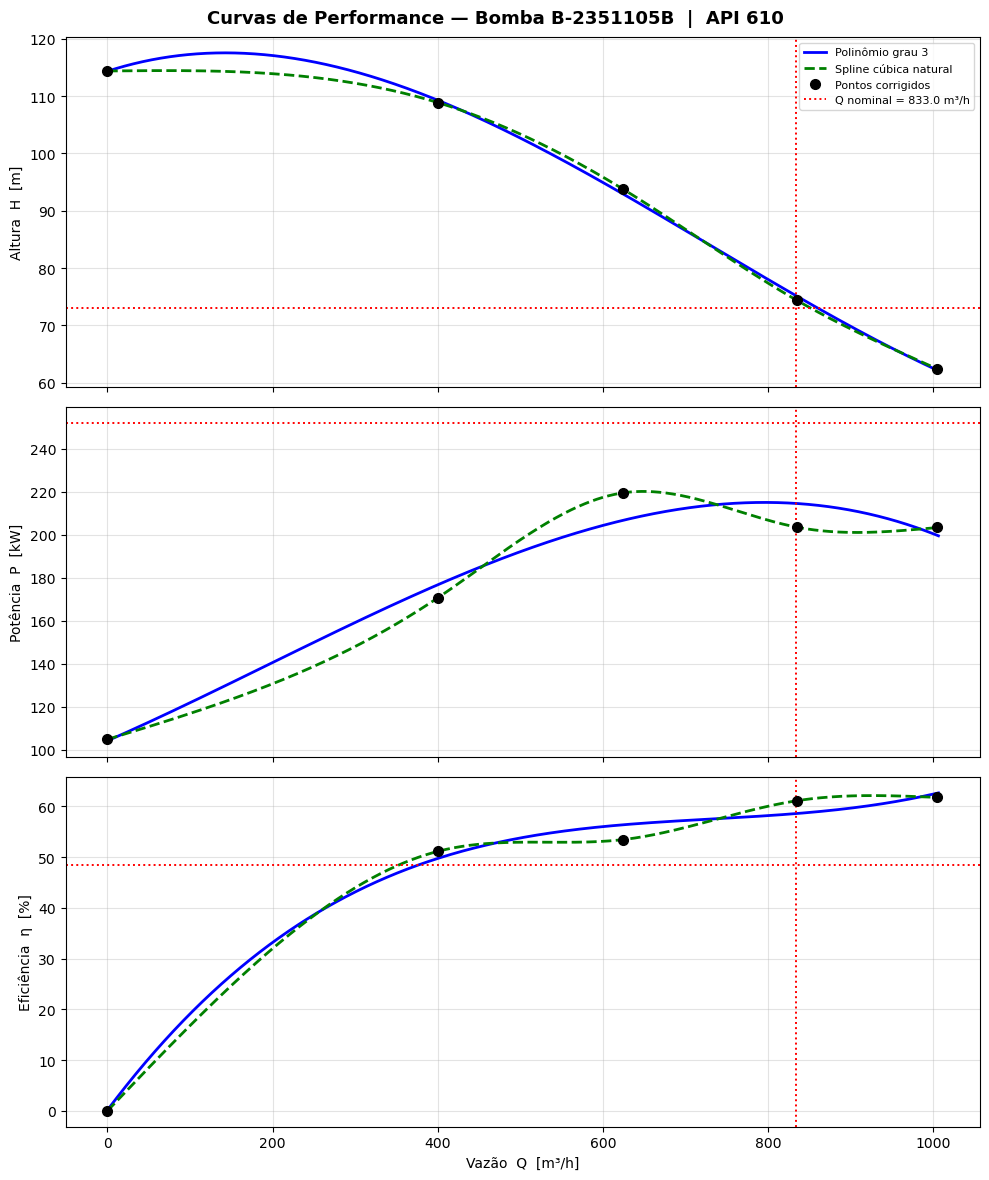

Figura salva em pump_api611_curvas.png


In [7]:
if 'Q' not in globals() or 'RATED' not in globals():
    print("[AVISO] Execute o formulário (célula 2) e clique em 'Calcular e Gerar Gráfico' antes de executar esta célula.")
elif not HAS_MPL:
    print("Instale matplotlib para ver os gráficos:  pip install matplotlib")
else:
    q_range  = [i * 0.5 for i in range(int(max(Q) / 0.5) + 4)]

    h_poly_c = [poly_eval(coeff_h, q) for q in q_range]
    h_spln_c = [sp_h.eval(q)          for q in q_range]
    p_poly_c = [poly_eval(coeff_p, q) for q in q_range]
    p_spln_c = [sp_p.eval(q)          for q in q_range]
    e_poly_c = [poly_eval(coeff_e, q) for q in q_range]
    e_spln_c = [sp_e.eval(q)          for q in q_range]

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(
        "Curvas de Performance — Bomba B-2351105B  |  API 610",
        fontsize=13, fontweight="bold", y=0.98
    )

    # Q × H
    ax = axes[0]
    ax.plot(q_range, h_poly_c, "b-",  lw=2,   label="Polinômio grau 3")
    ax.plot(q_range, h_spln_c, "g--", lw=2,   label="Spline cúbica natural")
    ax.plot(Q, H, "ko", ms=7, zorder=5,        label="Pontos corrigidos")
    ax.axvline(RATED.q_m3h,  color="red", ls=":", lw=1.4,
               label=f"Q nominal = {RATED.q_m3h} m³/h")
    ax.axhline(RATED.head_m, color="red", ls=":", lw=1.4)
    ax.set_ylabel("Altura  H  [m]")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.35)

    # Q × P
    ax = axes[1]
    ax.plot(q_range, p_poly_c, "b-",  lw=2)
    ax.plot(q_range, p_spln_c, "g--", lw=2)
    ax.plot(Q, P, "ko", ms=7, zorder=5)
    ax.axvline(RATED.q_m3h,   color="red", ls=":", lw=1.4)
    ax.axhline(RATED.power_kw, color="red", ls=":", lw=1.4)
    ax.set_ylabel("Potência  P  [kW]")
    ax.grid(True, alpha=0.35)

    # Q × η
    ax = axes[2]
    ax.plot(q_range, [v*100 for v in e_poly_c], "b-",  lw=2)
    ax.plot(q_range, [v*100 for v in e_spln_c], "g--", lw=2)
    ax.plot(Q, [v*100 for v in EF], "ko", ms=7, zorder=5)
    ax.axvline(RATED.q_m3h, color="red", ls=":", lw=1.4)
    if RATED.eff:
        ax.axhline(RATED.eff*100, color="red", ls=":", lw=1.4)
    ax.set_ylabel("Eficiência  η  [%]")
    ax.set_xlabel("Vazão  Q  [m³/h]")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig(r"c:\Users\U3BN\pump_api611_curvas.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura salva em pump_api611_curvas.png")

## 6 · Avaliação de Desvios e Tolerâncias API 610

Desvio calculado conforme a planilha:

$$\delta = 1 - \frac{\text{valor nominal}}{\text{valor predito pela curva}}$$

| Parâmetro | Tolerância (H ≤ 300 m) | Tolerância (H > 300 m) |
|---|:---:|:---:|
| Altura H | ±3 % | ±3 % |
| Potência P | ±8 % | ±5 % |
| H no shutoff | ±8 % | ±5 % |

In [8]:
def head_tol(h: float) -> float:
    return 0.03  # ±3 % independente da faixa (células J27 da planilha)

def power_tol(h: float) -> float:
    if h <= 75:   return 0.03
    if h <= 300:  return 0.08
    return 0.05

def deviation(nominal: Optional[float], predicted: float) -> Optional[float]:
    if not nominal or predicted == 0:
        return None
    return 1.0 - nominal / predicted

def status(dev: Optional[float], tol: float, name: str = "") -> str:
    if dev is None:
        return "N/A"
    if name.startswith("Pot"):
        ok = dev <= tol
    elif name.startswith("Ef"):
        ok = dev >= -tol
    else:
        ok = abs(dev) <= tol
    return "✅ APROVADO" if ok else "❌ REPROVADO"


if 'RATED' not in globals() or 'coeff_h' not in globals():
    print("[AVISO] Execute o formulário (célula 2) e clique em 'Calcular e Gerar Gráfico' antes de executar esta célula.")
else:
    qr = RATED.q_m3h

    h_poly  = poly_eval(coeff_h, qr);  h_spln  = sp_h.eval(qr)
    p_poly  = poly_eval(coeff_p, qr);  p_spln  = sp_p.eval(qr)
    e_poly  = poly_eval(coeff_e, qr);  e_spln  = sp_e.eval(qr)
    h0_poly = poly_eval(coeff_h, 0.0); h0_spln = sp_h.eval(0.0)

    tH = head_tol(RATED.head_m)
    tP = power_tol(RATED.head_m)

    rows = [
        ("Altura  H   (polinômio)", RATED.head_m,       h_poly,  deviation(RATED.head_m,       h_poly),  tH),
        ("Altura  H   (spline)   ", RATED.head_m,       h_spln,  deviation(RATED.head_m,       h_spln),  tH),
        ("Potência P  (polinômio)", RATED.power_kw,     p_poly,  deviation(RATED.power_kw,     p_poly),  tP),
        ("Potência P  (spline)   ", RATED.power_kw,     p_spln,  deviation(RATED.power_kw,     p_spln),  tP),
        ("Eficiência η (polinômio)", RATED.eff,         e_poly,  deviation(RATED.eff,          e_poly),  tP),
        ("Eficiência η (spline)  ", RATED.eff,          e_spln,  deviation(RATED.eff,          e_spln),  tP),
        ("H shutoff   (polinômio)", RATED.head_shutoff_m, h0_poly, deviation(RATED.head_shutoff_m, h0_poly), tP),
        ("H shutoff   (spline)   ", RATED.head_shutoff_m, h0_spln, deviation(RATED.head_shutoff_m, h0_spln), tP),
    ]

    fmt = "{:<28} {:>10} {:>10} {:>9} {:>5}  {}"
    print(fmt.format("Parâmetro", "Nominal", "Predito", "Desvio", "Tol.", "Status"))
    print("─" * 88)
    for name, nom, pred, dev, tol in rows:
        nom_s  = f"{nom:.3f}"  if nom  is not None else "N/A"
        pred_s = f"{pred:.3f}" if pred is not None else "N/A"
        dev_s  = f"{dev*100:+.2f}%" if dev is not None else "N/A"
        print(fmt.format(name, nom_s, pred_s, dev_s, f"{tol*100:.0f}%", status(dev, tol, name)))

Parâmetro                       Nominal    Predito    Desvio  Tol.  Status
────────────────────────────────────────────────────────────────────────────────────────
Altura  H   (polinômio)          73.000     75.217    +2.95%    3%  ✅ APROVADO
Altura  H   (spline)             73.000     74.490    +2.00%    3%  ✅ APROVADO
Potência P  (polinômio)         252.000    214.576   -17.44%    3%  ✅ APROVADO
Potência P  (spline)            252.000    203.645   -23.74%    3%  ✅ APROVADO
Eficiência η (polinômio)          0.484      0.586   +17.43%    3%  ✅ APROVADO
Eficiência η (spline)             0.484      0.611   +20.81%    3%  ✅ APROVADO
H shutoff   (polinômio)         117.000    114.364    -2.31%    3%  ✅ APROVADO
H shutoff   (spline)            117.000    114.408    -2.27%    3%  ✅ APROVADO


## 7 · Salvar Relatório em Arquivo de Dados

Exporta todos os resultados (pontos corrigidos, predições, desvios, tolerâncias e parecer) para um arquivo de dados reutilizável.

In [9]:
if 'RATED' not in globals() or 'CORRECTED' not in globals() or 'h_poly' not in globals():
    print("[AVISO] Execute o formulário (célula 2) e clique em 'Calcular e Gerar Gráfico' antes de executar esta célula.")
else:
    report = {
        "bomba": globals().get("PUMP_TAG", "Bomba"),
        "norma": "API 610",
        "ponto_nominal": RATED.__dict__,
        "pontos_corrigidos": [p.__dict__ for p in CORRECTED],
        "predicoes_ponto_nominal": {
            "head_poly_m":           h_poly,
            "head_spline_m":         h_spln,
            "power_poly_kw":         p_poly,
            "power_spline_kw":       p_spln,
            "eff_poly":              e_poly,
            "eff_spline":            e_spln,
            "head_shutoff_poly_m":   h0_poly,
            "head_shutoff_spline_m": h0_spln,
        },
        "desvios": {
            "head_poly":           deviation(RATED.head_m,         h_poly),
            "head_spline":         deviation(RATED.head_m,         h_spln),
            "power_poly":          deviation(RATED.power_kw,       p_poly),
            "power_spline":        deviation(RATED.power_kw,       p_spln),
            "eff_poly":            deviation(RATED.eff,            e_poly),
            "eff_spline":          deviation(RATED.eff,            e_spln),
            "head_shutoff_poly":   deviation(RATED.head_shutoff_m, h0_poly),
            "head_shutoff_spline": deviation(RATED.head_shutoff_m, h0_spln),
        },
        "tolerancias": {"head": tH, "power": tP},
        "parecer": {
            name.strip(): status(dev, tol, name)
            for name, _, _, dev, tol in rows
        },
    }

    OUTPUT = r"c:\Users\U3BN\pump_api611_resultado.json"
    with open(OUTPUT, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    print(f"Relatório salvo em: {OUTPUT}")

Relatório salvo em: c:\Users\U3BN\pump_api611_resultado.json
